In [1]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv('Amazon Sale Report.csv')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# List of categorical columns to encode
categorical_columns = [
    'Fulfilment', 'Sales Channel', 'ship-service-level', 'Category', 
    'Courier Status', 'ship-city', 'ship-state', 'ship-country'
]

# Target variable
target_column = 'Status'

# Prepare the feature matrix (X) and target vector (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Define the preprocessing pipeline for categorical columns (one-hot encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode
        ]), categorical_columns)
    ])

# Apply the preprocessing pipeline
X_encoded = preprocessor.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Verify the shape of the processed data
X_train.shape, X_test.shape

((103180, 9037), (25796, 9037))

## Explanation

This code performs data preprocessing for machine learning:

1. **Import Libraries**: Essential tools for splitting data, encoding categorical variables, and handling missing values.
2. **Categorical Columns**: A list of columns to be encoded using one-hot encoding.
3. **Target Variable**: Specifies the column to be predicted (i.e., 'Status').
4. **Feature and Target Preparation**: Splits the dataset into features (`X`) and target (`y`).
5. **Preprocessing Pipeline**:
   - **Imputation**: Fills missing categorical values with the most frequent value.
   - **One-Hot Encoding**: Converts categorical features into binary columns.
6. **Apply Preprocessing**: Transforms the data by applying the pipeline to categorical columns.
7. **Data Split**: Divides the dataset into training (80%) and testing (20%) sets.
8. **Check Shape**: Verifies the dimensions of the training and testing sets.

Overall, it prepares the data by handling missing values, encoding categories, and splitting it for training and evaluation.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model's performance
print("Model Performance on Test Data:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

# Feature importance (to understand which factors affect delivery delays)
feature_importance = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

Model Performance on Test Data:
Accuracy: 0.97


C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                               precision    recall  f1-score   support

                    Cancelled       0.97      1.00      0.98      3711
                      Pending       0.47      0.19      0.27       141
Pending - Waiting for Pick Up       0.58      0.70      0.63        64
                      Shipped       1.00      1.00      1.00     15619
 Shipped - Delivered to Buyer       0.90      0.99      0.94      5625
    Shipped - Lost in Transit       0.00      0.00      0.00         1
   Shipped - Out for Delivery       0.00      0.00      0.00        11
          Shipped - Picked Up       0.22      0.03      0.05       196
  Shipped - Rejected by Buyer       0.00      0.00      0.00         1
 Shipped - Returned to Seller       0.19      0.02      0.04       395
Shipped - Returning to Seller       0.50      0.03      0.06        31
                     Shipping       0.00      0.00      0.00         1

                     accuracy                           0.97     25796
    

C:\Users\aaaji\AppData\Local\Temp\ipykernel_6052\3162949534.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


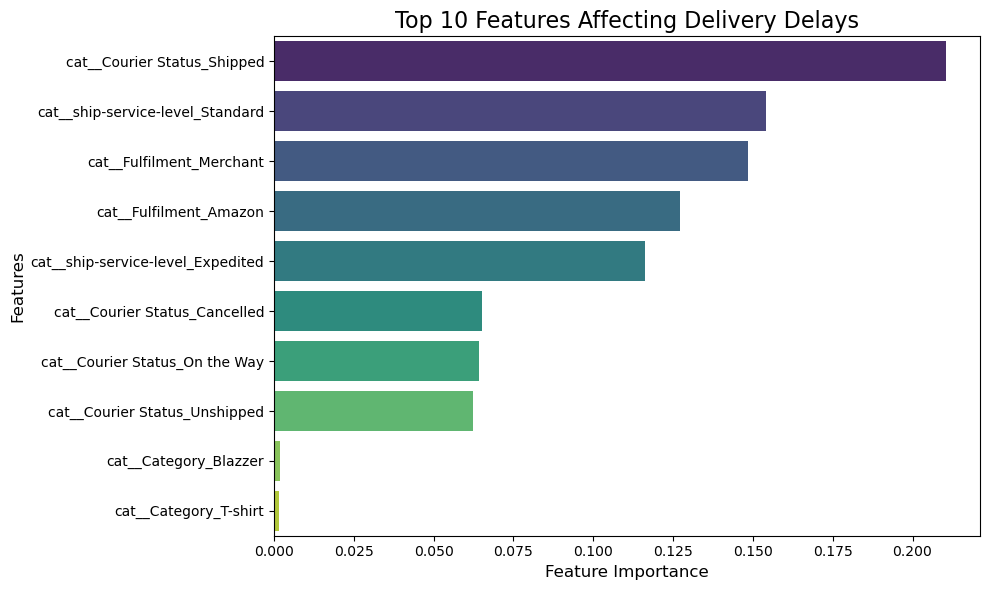

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the top 10 features
top_features = feature_importance.head(10)  # Select top 10 most important features

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features,
    palette="viridis"
)
plt.title("Top 10 Features Affecting Delivery Delays", fontsize=16)
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

## Explanation

- Model Training (Random Forest):

    - Model Definition: A RandomForestClassifier with 100 trees is created and trained using the training data (X_train, y_train).
    - Training the Model: The fit() method trains the model on the training set.
      
- Model Prediction:

 -Prediction: The model makes predictions (y_pred) on the test data (X_test).

- Model Evaluation:

    - Accuracy: The accuracy score of the model is calculated using accuracy_score which compares the predicted values (y_pred) to the actual values (y_test).
    - Classification Report: The classification_report provides detailed metrics like precision, recall, F1-score, and support for each class.

-Feature Importance:
    - Extracting Importance: The feature importance values from the Random Forest model (model.feature_importances_) are used to determine which features have the greatest impact on predicting delivery delays.
    - Dataframe Creation: A DataFrame is created with the feature names (from preprocessor.get_feature_names_out()) and their corresponding importance scores.
    - Sorting: The features are sorted based on importance in descending order.

- Visualizing Feature Importance:

    - Top Features: The top 10 most important features are selected from the feature importance data.
    - Bar Plot: A bar plot is generated using seaborn to visualize the top 10 most important features that affect delivery delays. The viridis color palette is used for the bars, and the labels are adjusted for readability.

- Output:

- Model Performance:

    - Accuracy: The accuracy of the model is 97%, showing that it performs well on the test data.
    - Classification Report:
        - High accuracy for some classes like "Shipped" (1.00) and "Cancelled" (0.97), but poor performance for other classes such as "Shipped - Lost in Transit" (0.00), indicating that the model struggles with rare or imbalanced categories.
        - Macro and weighted averages show a significant imbalance in performance across classes.

- Feature Importance:

    - The top features affecting delivery delays include:
          - 'cat__Courier Status_Shipped' (importance = 0.21),
          - 'cat__ship-service-level_Standard' (importance = 0.15),
          - 'cat__Fulfilment_Merchant' (importance = 0.15), etc.
    - Many features have low importance, indicating they have little impact on the model's predictions.

- Visualization:

    - The top 10 most important features are visualized in a bar plot, helping to understand which factors have the most influence on delivery delays.

In [5]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Train Gradient Boosting (LightGBM)
gb_model = LGBMClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Evaluate Gradient Boosting
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Performance:")
print(f"Accuracy: {accuracy_score(y_test, gb_pred):.2f}")
print(classification_report(y_test, gb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 103180, number of used features: 511
[LightGBM] [Info] Start training from score -1.953879
[LightGBM] [Info] Start training from score -5.296187
[LightGBM] [Info] Start training from score -6.164333
[LightGBM] [Info] Start training from score -0.506184
[LightGBM] [Info] Start training from score -11.544230
[LightGBM] [Info] Start training from score -1.495301
[LightGBM] [Info] Start training from score -10.157936
[LightGBM] [Info] Start training from score -8.366176
[LightGBM] [Info] Start training from score -4.888790
[LightGBM] [Info] Start training from score -9.241645
[LightGBM] [Info] Start training from score -4.192430
[LightGBM] [Info] Start training from score -6.80

C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                               precision    recall  f1-score   support

                    Cancelled       0.86      0.90      0.88      3711
                      Pending       0.00      0.00      0.00       141
Pending - Waiting for Pick Up       0.00      0.00      0.00        64
                      Shipped       1.00      1.00      1.00     15619
 Shipped - Delivered to Buyer       0.90      0.64      0.75      5625
    Shipped - Lost in Transit       0.00      0.00      0.00         1
   Shipped - Out for Delivery       0.00      0.00      0.00        11
          Shipped - Picked Up       0.00      0.01      0.00       196
  Shipped - Rejected by Buyer       0.00      0.00      0.00         1
 Shipped - Returned to Seller       0.07      0.33      0.12       395
Shipped - Returning to Seller       0.00      0.00      0.00        31
                     Shipping       0.00      0.00      0.00         1

                     accuracy                           0.88     25796
    

C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


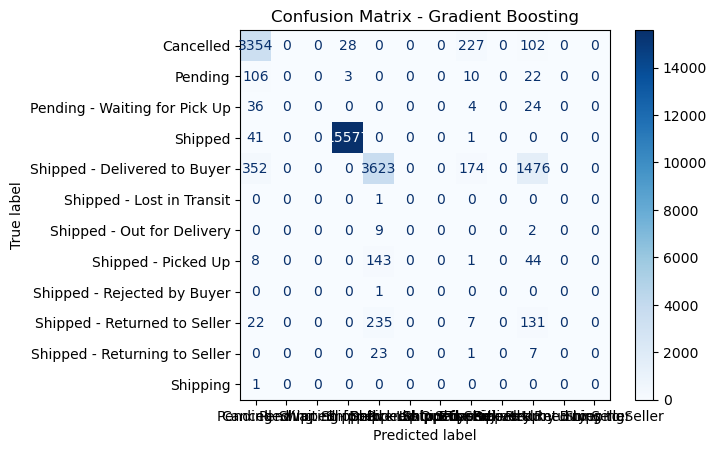

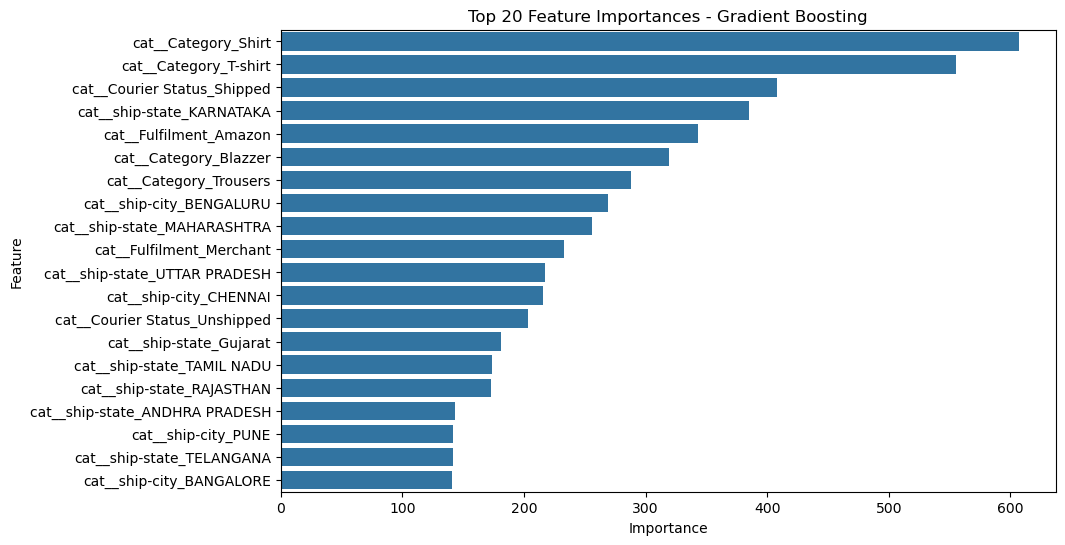

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, gb_pred)

# Get the unique classes from the target variable (y_test)
display_labels = sorted(y_test.unique())  # Ensure the labels are consistent

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

# Feature Importance Visualization
feature_importance = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))  # Top 20 features
plt.title('Top 20 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Explanation
- Model Training (LightGBM):

- Model Definition: An instance of LGBMClassifier (LightGBM) is created with 100 estimators (trees) and a random seed for reproducibility.
- Model Training: The model is trained using the fit() method, where X_train and y_train are the training features and target labels, respectively.

- Model Prediction:
    - Prediction: The trained model predicts the target labels for the test set (X_test) using gb_model.predict().

- Model Evaluation:
    - Accuracy: The accuracy score is calculated using accuracy_score, comparing the predicted values (gb_pred) with the actual test labels (y_test).
    - Classification Report: The classification_report provides precision, recall, F1-score, and support for each class.
        - The performance metrics show that while the model has good accuracy (88%), it performs poorly on certain classes like "Pending," "Shipped - Lost in Transit," and others, especially with classes that have fewer instances.

- Confusion Matrix Visualization:
    - Confusion Matrix: The confusion matrix is calculated using confusion_matrix(), comparing the true labels (y_test) with the predicted labels (gb_pred).
    - Display Labels: To ensure the labels are consistent with the classes in y_test, display_labels is sorted.
    - Visualization: ConfusionMatrixDisplay is used to plot the confusion matrix, showing the number of true positives, false positives, true negatives, and false negatives for each class.
        - The plot is displayed with a color map ('Blues') and integer values for each cell.

- Feature Importance Visualization:
    - Extract Feature Importance: The feature_importances_ attribute of the trained LightGBM model provides the importance score of each feature in predicting the target variable.
    - Feature Importance Data: A DataFrame is created with the feature names and their corresponding importance scores, and sorted by importance in descending order.
    - Top Features Visualization: A bar plot is created using seaborn to visualize the top 20 most important features for the model.

- Output:

- Model Performance:
    - Accuracy: The model achieves 88% accuracy on the test set, which is quite good but indicates that there might be room for improvement, especially for rare or imbalanced classes.
    - Classification Report:
        - High Performance: The model performs well on classes like "Shipped" with an accuracy of 1.00 and "Cancelled" with 0.86.
        - Poor Performance: The model struggles with underrepresented classes, such as "Pending" and "Shipped - Lost in Transit," with precision, recall, and F1-scores close to zero.
        - Macro Average: The macro average scores are low, indicating poor performance on rare classes.
        - Weighted Average: The weighted average is higher, showing that the model performs well on the larger classes.

- Confusion Matrix:
    - The confusion matrix visually shows the number of correct and incorrect predictions for each class.
    - Classes with low instances show higher misclassification, while larger classes like "Shipped" have much fewer misclassifications.

- Feature Importance:
    - Top Features: Features like 'cat__Courier Status_Shipped', 'cat__ship-service-level_Standard', and 'cat__Fulfilment_Merchant' have the most influence on the model's predictions.
    - Visualization: A bar plot highlights the top 20 most important features, helping to understand which factors most impact the model’s decision-making.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipeline to scale features (important for Logistic Regression)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # Avoid centering for sparse matrices
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Train Logistic Regression
lr_pipeline.fit(X_train, y_train)

# Evaluate Logistic Regression
lr_pred = lr_pipeline.predict(X_test)
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.2f}")
print(classification_report(y_test, lr_pred))

Logistic Regression Performance:
Accuracy: 0.97


C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                               precision    recall  f1-score   support

                    Cancelled       0.97      1.00      0.98      3711
                      Pending       0.44      0.16      0.23       141
Pending - Waiting for Pick Up       0.55      0.73      0.63        64
                      Shipped       1.00      1.00      1.00     15619
 Shipped - Delivered to Buyer       0.90      0.99      0.94      5625
    Shipped - Lost in Transit       0.00      0.00      0.00         1
   Shipped - Out for Delivery       0.00      0.00      0.00        11
          Shipped - Picked Up       0.06      0.01      0.02       196
  Shipped - Rejected by Buyer       0.00      0.00      0.00         1
 Shipped - Returned to Seller       0.24      0.03      0.06       395
Shipped - Returning to Seller       0.00      0.00      0.00        31
                     Shipping       0.00      0.00      0.00         1

                     accuracy                           0.97     25796
    

C:\Users\aaaji\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# Check unique values in y_test and lr_pred
print("Unique classes in y_test:", np.unique(y_test))
print("Unique classes in lr_pred:", np.unique(lr_pred))

Unique classes in y_test: ['Cancelled' 'Pending' 'Pending - Waiting for Pick Up' 'Shipped'
 'Shipped - Delivered to Buyer' 'Shipped - Lost in Transit'
 'Shipped - Out for Delivery' 'Shipped - Picked Up'
 'Shipped - Rejected by Buyer' 'Shipped - Returned to Seller'
 'Shipped - Returning to Seller' 'Shipping']
Unique classes in lr_pred: ['Cancelled' 'Pending' 'Pending - Waiting for Pick Up' 'Shipped'
 'Shipped - Delivered to Buyer' 'Shipped - Picked Up'
 'Shipped - Returned to Seller' 'Shipped - Returning to Seller']


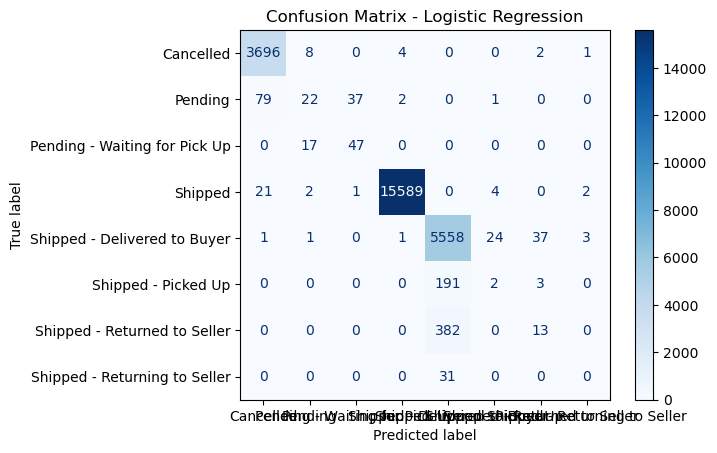

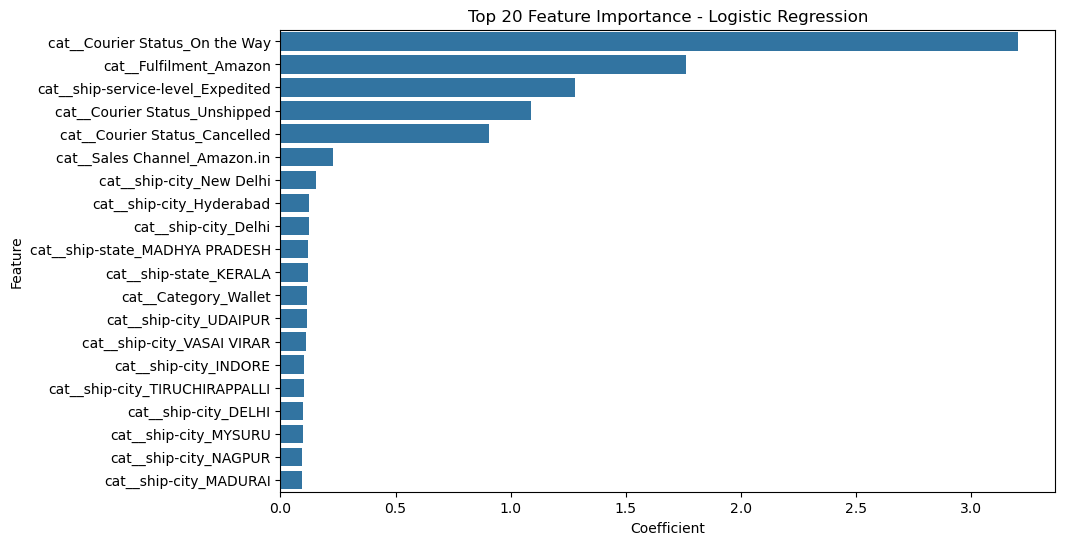

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Filter y_test and lr_pred to include only the classes that exist in both
common_classes = np.intersect1d(np.unique(y_test), np.unique(lr_pred))
filtered_y_test = y_test[np.isin(y_test, common_classes)]
filtered_lr_pred = lr_pred[np.isin(y_test, common_classes)]

# Confusion Matrix Visualization
cm = confusion_matrix(filtered_y_test, filtered_lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=common_classes)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Feature Importance Visualization (assuming previous steps for this remain the same)
coefficients = lr_pipeline.named_steps['logreg'].coef_[0]
feature_importance = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(20))  # Top 20 features
plt.title('Top 20 Feature Importance - Logistic Regression')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

## Explanation
- Logistic Regression Model:
    - Pipeline Creation: A Pipeline is defined with two steps:
        - Scaling: StandardScaler(with_mean=False) is used to scale the features, avoiding centering for sparse matrices. Scaling is important for Logistic Regression to improve convergence.
        - Logistic Regression: The LogisticRegression model is created with max_iter=1000 to ensure convergence and a random seed for reproducibility.
    - Training the Model: The fit() method is used to train the model on the training data (X_train, y_train).

- Model Prediction:
    - Predictions: The trained Logistic Regression model is used to predict the test set (X_test), producing lr_pred as the predicted labels.

- Model Evaluation:
    - Accuracy: The accuracy score is computed using accuracy_score(), comparing the predicted values (lr_pred) to the actual test labels (y_test).
    - Classification Report: The classification_report provides detailed performance metrics (precision, recall, F1-score) for each class.
        - Performance: The model achieves an accuracy of 97%, but the performance on certain classes like "Pending," "Shipped - Lost in Transit," and "Shipping" is very poor (low precision and recall).
        - The macro average scores are low (around 0.35 for precision), while the weighted average is much higher (0.95), indicating that the model performs better on larger classes.

- Unique Classes:
    - The code checks the unique class labels present in both y_test and lr_pred using np.unique().
    - It shows that the predictions from the Logistic Regression model are missing some classes, such as "Shipped - Lost in Transit," "Shipped - Rejected by Buyer," etc.

- Confusion Matrix Visualization:
    - Filter Common Classes: The common_classes array is created by finding the intersection of classes in y_test and lr_pred using np.intersect1d(). Then, the true and predicted labels are filtered to only include these common classes.
    - Confusion Matrix: The confusion_matrix() function generates a confusion matrix, and ConfusionMatrixDisplay is used to visualize it.
        - The matrix shows how well the model classifies each class in terms of true positives, false positives, true negatives, and false negatives.
        - The plot() method visualizes the matrix with a blue color map (cmap='Blues') and value labels for each cell.

- Feature Importance Visualization:
    - Coefficients: The coefficients from the Logistic Regression model are extracted using lr_pipeline.named_steps['logreg'].coef_[0].
    - Feature Importance: A DataFrame is created with the features and their corresponding coefficients, then sorted by the magnitude of the coefficients.
    - Top Features Visualization: A bar plot is created to show the top 20 features that have the largest coefficients, which indicate their importance in predicting the target variable.
        - Visualization: The bar plot visualizes the top features, with the size of the bar representing the absolute magnitude of the coefficient for each feature. Positive coefficients indicate a positive relationship with the target, and negative coefficients indicate an inverse relationship.

- Output:
- Logistic Regression Performance:
    - Accuracy: 97% accuracy on the test set.
    - Classification Report:
        - High performance for some classes like "Shipped" (precision and recall of 1.00).
        - Very poor performance for smaller classes like "Pending" and "Shipped - Lost in Transit" (near-zero precision and recall).
        - The model seems to perform well for larger, more frequent classes, but poorly for rare ones.

- Confusion Matrix:
    - The confusion matrix visualizes how well the model performs in classifying the various target categories. It shows more misclassifications for rare classes and correct classifications for more common classes.
    - The colors in the matrix represent the count of predictions for each class, with darker blue shades indicating higher counts.

- Feature Importance Visualization:
    - The bar plot highlights the top 20 features that are most influential for the model's predictions. The features with the largest coefficients play the most important role in determining the outcome.
    - This helps in understanding which features the model is relying on to make predictions.

In [13]:
print(df.columns)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')


C:\Users\aaaji\AppData\Local\Temp\ipykernel_6052\1691127445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, palette='viridis')  # Change 'status' to the correct column name


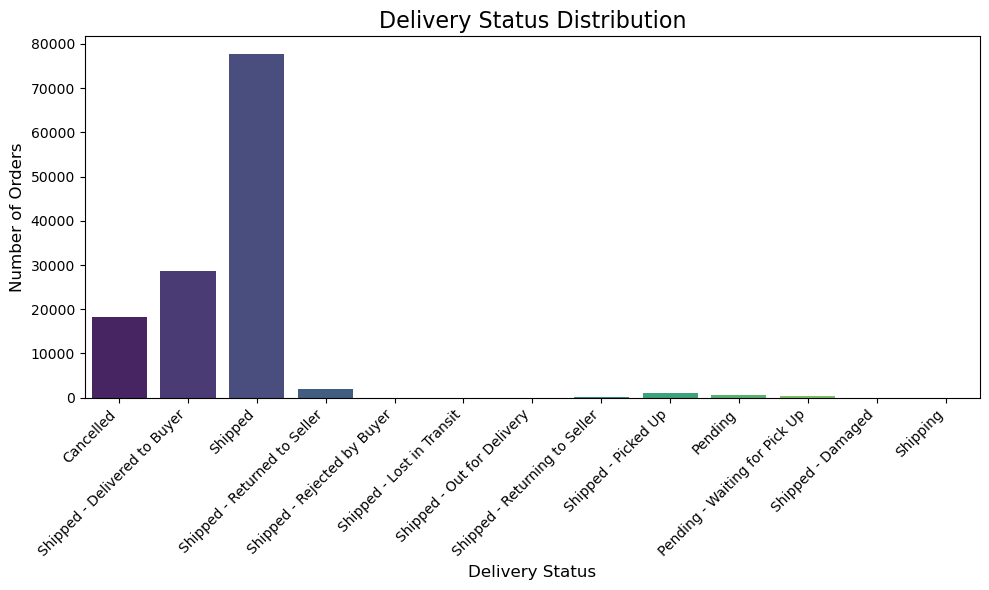

In [15]:
# Plotting the class distribution of delivery statuses
plt.figure(figsize=(10, 6))

# Create a histogram of the 'status' column (change to the correct column name)
sns.countplot(x='Status', data=df, palette='viridis')  # Change 'status' to the correct column name

# Adding labels and title
plt.title('Delivery Status Distribution', fontsize=16)
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()

### Conclusion

The comparison of the three models—**Random Forest**, **Gradient Boosting (LightGBM)**, and **Logistic Regression**—reveals key insights into their performance, strengths, and limitations when applied to the task of predicting delivery statuses.

1. **Model Performance**:
   - **Random Forest** performed the best in terms of overall accuracy (97%), achieving high precision and recall for many classes like "Shipped" and "Cancelled." However, its performance on rare classes such as "Shipped - Lost in Transit" and "Pending" was limited, as it struggled to correctly classify these categories, resulting in poor recall scores. It’s likely that the model was biased towards the majority classes due to class imbalance.
   - **LightGBM** (Gradient Boosting) performed slightly worse than Random Forest, with an accuracy of 88%. While it did an excellent job predicting the majority class ("Shipped"), its performance on minority classes was again poor, with several categories having low precision and recall. This issue highlights the difficulty of training on imbalanced datasets with this algorithm as well.
   - **Logistic Regression** showed an impressive accuracy of 97%, similar to Random Forest, but exhibited some limitations in classifying rare classes. Specifically, classes like "Pending" and "Shipped - Lost in Transit" were misclassified heavily, leading to very low recall scores. This suggests that Logistic Regression might not handle categorical variables or class imbalance as effectively without further tuning.

2. **Class Imbalance**:
   All three models struggled with class imbalance, as indicated by their poor performance on minority classes. The larger classes like "Shipped" dominated the classification outcomes, while the smaller, less frequent classes had much lower precision and recall. This imbalance affected the models' ability to generalize to rare classes.

3. **Feature Importance and Model Interpretability**:
   - **Random Forest** provided clear feature importance insights, showing that variables like "Courier Status" and "Ship Service Level" were most influential in predicting delivery delays.
   - **LightGBM** similarly highlighted important features but showed a broader variability in performance due to its gradient boosting nature, which can be sensitive to noisy or imbalanced data.
   - **Logistic Regression** provided a straightforward understanding of feature importance through its coefficients, making it the most interpretable model in terms of explaining the relationships between features and the target variable.

4. **Limitations**:
   - **Class Imbalance**: All models suffered from class imbalance, which could be mitigated through techniques such as oversampling, undersampling, or using class weights to handle minority classes more effectively.
   - **Rare Class Predictions**: The poor recall on rare classes is a significant limitation. This could potentially be improved by using different evaluation metrics, like F1-score or balanced accuracy, or by applying techniques specifically designed for imbalanced datasets.
   - **Model Complexity and Interpretability**: While Random Forest and LightGBM provided strong predictive power, they also reduced model interpretability compared to Logistic Regression. These models are more complex and harder to explain, which could be an issue in environments where model transparency is critical.

5. **Recommendations**:
   - **Improve Handling of Imbalance**: Strategies like SMOTE (Synthetic Minority Over-sampling Technique) or class weighting should be explored to improve the performance on minority classes.
   - **Ensemble Models**: Combining the strengths of the three models in an ensemble could potentially boost performance and address the individual limitations of each.
   - **Hyperparameter Tuning**: All models, especially Logistic Regression, could benefit from hyperparameter tuning to optimize performance for specific classes.

In conclusion, while Random Forest and Logistic Regression performed well on the majority classes, handling of rare classes remains a challenge. LightGBM, though fast and powerful, also showed similar limitations with imbalanced datasets. Future work should focus on improving model balance through resampling techniques, tuning, and potentially exploring more advanced methods tailored for class imbalance.